# zlabel — the `cluster → labelling → labels` workflow, end to end

A single scRNA-seq **cluster** comes in as a ranked list of **marker genes** (+ a developmental
stage); a **`Label`** evidence packet comes out. This notebook follows one cluster all the way
through, **running the real engine** and printing every intermediate, so the algorithm stops being
a black box.

> **The one idea that makes it click:** the curated panels are the *prior*, **not** the *namer*.
> A panel only proposes a coarse bucket and hands the namer a ZFA anatomy *anchor*. The actual name
> comes from **descending the ZFA ontology** along the path the markers' real ZFIN expression
> converges on — so the label's **depth is *earned from evidence***, not fixed by the panel.

Three signals converge: **panel overlap** (prior + anchor) · **ZFA expression convergence**
(the namer) · **stage plausibility** (a check). When they agree → a confident, deep call; when they
don't → an honest abstention that still hands back the *forcing evidence*.

*Companion reference:* [`workflow_map.md`](workflow_map.md) (the mental model + every `file:line`
anchor). *Visual companion:* `../../../zlabel-scope` renders this same trace as an interactive DAG.

*Runs on the real 93 MB ontology data already present under `data/ontologies/`.*

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

from zlabel import Labeler
from zlabel.genes import normalize_markers, resolved_symbols
from zlabel.panels import score_markers
from zlabel.data import children

# One Labeler loads every data authority once (ZFA anatomy, ZFIN wildtype expression, GAF gene
# synonyms, the panels) and builds the information-content + marker-specificity models. The default
# data dir resolves to <repo>/data/ontologies regardless of where the notebook runs.
# stage_hpf = 48.0 is the Long-pec stage (used for the stage-plausibility signal).
lab = Labeler(stage_hpf=48.0)
print("loaded:", len(lab._panels), "panels and",
      len(lab._expression_map), "genes with ZFIN expression records")

loaded: 33 panels and 14485 genes with ZFIN expression records


## 1 · The 30-second version

`Labeler.label(markers)` is the whole public job (`src/zlabel/label.py:1123`). Hand it the marker
genes of a clear blood-vessel-endothelium cluster and read the packet it returns.

In [2]:
ENDO = ["kdrl", "fli1a", "cdh5", "kdr", "etv2"]   # canonical blood-vessel endothelium markers
print(lab.label(ENDO).to_yaml())

bucket: blood vessel endothelial cell
levels:
- cardiovascular system
- multi-tissue structure
- unilaminar epithelium
- portion of tissue
- vasculature
- simple squamous epithelium
- barrier cell
- epithelium
- cell
- vascular endothelium
- lining cell
- epithelial cell
- blood vessel endothelium
- endothelial cell
- squamous epithelial cell
- blood vessel endothelial cell
depth: 16
abstained: false
confidence: high
confidence_score: 1.0
confidence_components:
  coherence: 1.0
  margin: 1.0
  grounding: 1.0
  stage: 1.0
ambiguity_flag: none
states: []
panel_bucket: endothelium
panel_germ_layer: mesoderm
zfa_id: ZFA:0009036
panel_scores:
  endothelium: 0.8539316501572937
  blood_erythroid: 0.0
  blood_lymphoid: 0.0
  cardiac: 0.0
  cartilage: 0.0
  cycling: 0.0
  endoderm_gut: 0.0
  epidermis: 0.0
  eye: 0.0
  fin: 0.0
  germline: 0.0
  glia: 0.0
  immune_myeloid: 0.0
  interrenal: 0.0
  intestine: 0.0
  ionocyte: 0.0
  lateral_line: 0.0
  liver: 0.0
  mesenchyme: 0.0
  mural: 0.0
  mu

Note already: `bucket: blood vessel endothelial cell` with `depth: 16` and `confidence: high` — a
deep, specific call. `panel_bucket: endothelium` shows the coarse prior it descended *from*. The
rest of the notebook opens the box that produced this.

## 2 · The pipeline at a glance

```mermaid
flowchart TD
    A["markers: list[str]<br/>+ stage_hpf"] --> B["normalize_markers<br/>genes.py:113"]
    B --> C["score_markers<br/>panels.py:195"]
    C --> D{"decide — the ladder<br/>label.py:489"}
    D -->|clear winner / rescue| E["resolve_label<br/>descend ZFA from the anchor<br/>resolve.py:323"]
    D -->|near-tie, one germ layer| F["germ-layer rollup"]
    D -->|no signal / doublet| G["abstain<br/>+ forcing evidence"]
    E --> H["Label packet<br/>models.py:88"]
    F --> H
    G --> H
```

`Labeler.label` (`label.py:1123`) is just: **normalize → score → decide**, with `decide` calling the
ZFA **descent** when it has a clear winner. Each stage below is run on its own.

## 3 · Stage 1 — Normalize  (`genes.py:113`)

Zebrafish symbols carry aliases, superseded names, and `a`/`b` paralog pairs. A valid marker can be
missed *purely* because the dataset used an old symbol — so every marker is mapped to its current
ZFIN symbol **before** anything else. Each marker becomes `resolved` (one current symbol),
`ambiguous` (a previous name → several paralogs), or `unresolved` (dropped from scoring).

In [3]:
# Old symbols + one junk gene, to see normalization earn its keep.
demo = ["mylz2", "fli1a", "etv2", "cdh5", "notagene"]
for nm in normalize_markers(demo, lab._synonyms):
    arrow = "  ->  " + ", ".join(sorted(nm.symbols)) if nm.symbols else ""
    print(f"  {nm.input:10s} [{nm.status:10s}]{arrow}")

# Only the resolved symbols flow downstream (note mylz2->mylpfa, fli1a->fli1, etv2->etsrp):
print("\nresolved & used:", resolved_symbols(normalize_markers(demo, lab._synonyms)))

  mylz2      [resolved  ]  ->  mylpfa
  fli1a      [resolved  ]  ->  fli1
  etv2       [resolved  ]  ->  etsrp
  cdh5       [resolved  ]  ->  cdh5
  notagene   [unresolved]

resolved & used: ['mylpfa', 'fli1', 'etsrp', 'cdh5']


## 4 · Stage 2 — Score panels  (`panels.py:195`)

The resolved markers are scored against the 33 curated panels (`src/zlabel/panels.yaml`) by
**rank-weighted overlap**: a marker at rank *r* contributes `1/log2(r+1)`, so the most significant
markers count most. The result is a ranked ladder of `BucketScore`s. **This is the coarse prior and
the descent anchor — not the final name.**

In [4]:
nm = normalize_markers(ENDO, lab._synonyms)
scores = score_markers(nm, lab._panels)

print(f"{'bucket':22s} {'score':>6s}  {'kind':9s} matched markers")
for bs in scores:
    if not bs.matched_markers:
        continue
    matched = ", ".join(m.symbol for m in bs.matched_markers)
    print(f"{bs.bucket:22s} {bs.score:6.2f}  {bs.kind:9s} {matched}")

bucket                  score  kind      matched markers
endothelium              0.85  identity  kdrl, fli1, cdh5, etsrp


## 5 · Stage 3 — Decide: the honesty ladder  (`label.py:489`)

`decide()` ranks the identity buckets by an **adjusted** score — the raw fraction recomputed with
state-only markers (cycling, stress) dropped from the *denominator*, so a state marker can't dilute
the identity call — and walks the ladder below. The whole point is to **refuse to overcall**:

```mermaid
flowchart TD
    S["identity buckets,<br/>sorted by adjusted score"] --> A{"any identity hit?"}
    A -->|no| AA["abstain · ood = no_signal"]
    A -->|yes| B{"top_adj ≥ MIN_SIGNAL (0.15)?"}
    B -->|no| BR{"a matched marker<br/>IDF ≥ 1/3?"}
    BR -->|yes| RES["specificity rescue → name"]
    BR -->|no| BB["abstain · ood = structural / in_set"]
    B -->|yes| C{"lead ≥ DOMINANCE_GAP (0.30)?<br/>(or only one bucket)"}
    C -->|yes| CC["clear winner → descend & name"]
    C -->|no| D{"contenders share<br/>one germ layer?"}
    D -->|yes| DD["germ-layer rollup<br/>(confidence capped at medium)"]
    D -->|no| DE["abstain · ood = doublet"]
```

`Labeler.trace()` records which branch fired and the adjusted ladder it ranked on (the designed
introspection surface — `models.py:335`). For the endothelium cluster only one identity bucket
matches, so it is an automatic clear winner.

In [5]:
T = lab.trace(ENDO)
print("branch taken:", T.branch, "\n")
print(f"{'bucket':22s} {'raw':>5s} {'adj':>5s}  role")
for bs in T.panel_scores:
    if not bs.matched_markers:
        continue
    role = "WINNER" if bs.is_winner else ("contender" if bs.is_contender else "")
    print(f"{bs.bucket:22s} {bs.score:5.2f} {bs.adjusted_score:5.2f}  {role}")

branch taken: clear-winner 

bucket                   raw   adj  role
endothelium             0.85  0.85  WINNER


## 6 · Stage 4 — Descend the ZFA ontology: the heart  (`resolve.py:323`)

This is where the *name* is made. The mechanism (`resolve.py:_descend`, line 253):

1. **Vote.** Each distinct gene looks up its ZFIN expression records and votes for every ZFA term it
   expresses in **plus all of that term's `is_a`/`part_of` ancestors** (a gene in *muscle cell* also
   credits *musculature system* and up).
2. **Seed.** Start at the winning panel's anchor — the most-supported anchor id (≥ `CONVERGENCE_MIN`
   = 3 genes).
3. **Descend.** Step into the best-supported child **only while** it keeps ≥ 3 genes **and** ≥ 60%
   of its parent's support (`DESCENT_SUPPORT_FRACTION`) **and** *uniquely* leads its siblings. If the
   top two children **tie**, the markers have spread across subtypes → **stop here**.

The deepest term the walk reaches *is* the label, and `depth` falls out of it. The helper below
draws the real walk straight from the trace — **green** = on the descent path · **gold ring** =
selected (the label) · **grey dashed** = a child the descent considered and rejected · `(Ng)` =
distinct genes supporting that term.

In [6]:
def draw_descent(trace, ontology, *, max_children=4, ax=None):
    """Draw a LabelTrace's ZFA descent: the path taken plus the rejected children at each step.

    Faithful to the engine — it reads the recorded term votes and the ontology's child edges, it
    never re-decides (the same rule zlabel-scope follows).

    Args:
        trace (LabelTrace): From Labeler.trace(markers).
        ontology (nx.MultiDiGraph): The loaded ZFA graph (lab._zfa_ontology).
        max_children (int): Cap on rejected children drawn per path node (keeps it readable).
        ax (matplotlib Axes | None): Axis to draw on; a new figure is made when None.

    Returns:
        matplotlib Axes: The axis drawn on.
    """
    votes = {v.zfa_id: v for v in trace.term_votes}
    path = sorted((v for v in votes.values() if v.on_descent_path),
                  key=lambda v: (v.ancestor_depth, v.zfa_id))  # zfa_id keeps the order stable on ties
    if not path:
        # The precheck/rollup/abstain branches never run the descent, so there is nothing to draw.
        if ax is None:
            _, ax = plt.subplots(figsize=(7, 1.2))
        ax.text(0.5, 0.5, f"no descent path (branch: {trace.branch})", ha="center", va="center")
        ax.axis("off")
        return ax
    G, pos, color = nx.DiGraph(), {}, {}
    spine, reject = [], []

    def add(v, x, y, c):
        G.add_node(v.zfa_id)
        pos[v.zfa_id] = (x, y)
        color[v.zfa_id] = c

    for i, v in enumerate(path):
        add(v, 0.0, -float(i), "#d4af37" if v.selected else "#3a7d44")
        if i:
            spine.append((path[i - 1].zfa_id, v.zfa_id))
        kids = [votes[k] for k in children(ontology, v.zfa_id)
                if k in votes and not votes[k].on_descent_path]
        for j, k in enumerate(sorted(kids, key=lambda k: -k.gene_count)[:max_children]):
            add(k, 1.4 + j * 1.35, -float(i) - 0.55, "#b8b8b8")
            reject.append((v.zfa_id, k.zfa_id))

    labels = {n: f"{votes[n].zfa_name}\n({votes[n].gene_count}g)" for n in G.nodes}
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 1.8 + 1.5 * len(path)))
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=spine, edge_color="#3a7d44", width=2.4)
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=reject, edge_color="#cccccc",
                           style="dashed", width=1.2)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=list(G.nodes),
                           node_color=[color[n] for n in G.nodes], node_size=2500,
                           edgecolors=["#7a5c00" if color[n] == "#d4af37" else "none" for n in G.nodes],
                           linewidths=2.5)
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=7)
    ax.set_title(f"branch: {trace.branch}  ->  {trace.label.bucket}  (depth {trace.label.depth})",
                 fontsize=10)
    ax.axis("off")
    return ax

**The honest stop.** Muscle markers seed at the broad anchor *musculature system* and immediately
stop: its two best children (*trunk musculature*, *muscle*) **tie at 6 genes each**, so the markers
are spread across subtypes rather than converging on one — the engine refuses to pick, and depth
stays at 1.

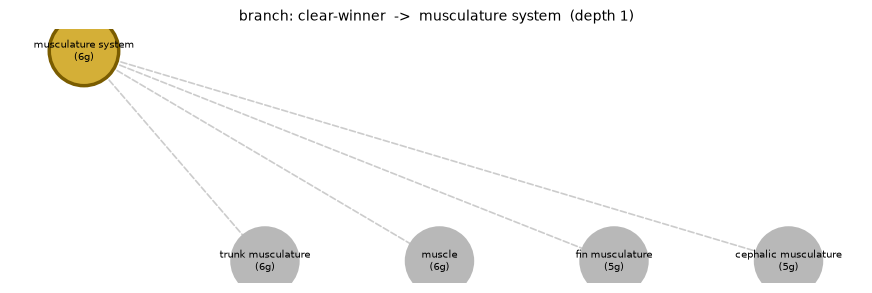

In [7]:
MUSCLE = ["mylz2", "acta1b", "tnnt3a", "myod1", "myog", "myf5"]
draw_descent(lab.trace(MUSCLE), lab._zfa_ontology)
plt.show()

**Depth is *specificity*, not step count.** Same code, same `clear-winner` branch, same high
confidence — but `depth` is the length of the `levels` chain: the non-stoplist ZFA terms from the
broadest ancestor down to *and including* the named term (*how specific the term is*), not how far
the walk travelled. The endothelium panel has two anchors (*vasculature* and *endothelial cell*);
the descent seeds at the most-supported one — here *endothelial cell*, which wins the tiebreaker
over *vasculature* by carrying higher information content — so a single step to *blood vessel
endothelial cell* (its only well-supported child; the sibling *endothelial tip cell* has just 1
gene) lands at **depth 16**. Muscle's anchor *musculature system* is a broad system whose own
ancestors are all generic (STOPLIST), so it sits at **depth 1** even though it made an equally
confident call. Depth tracks where the evidence placed the term in the ontology — not the panel,
and not the number of steps.

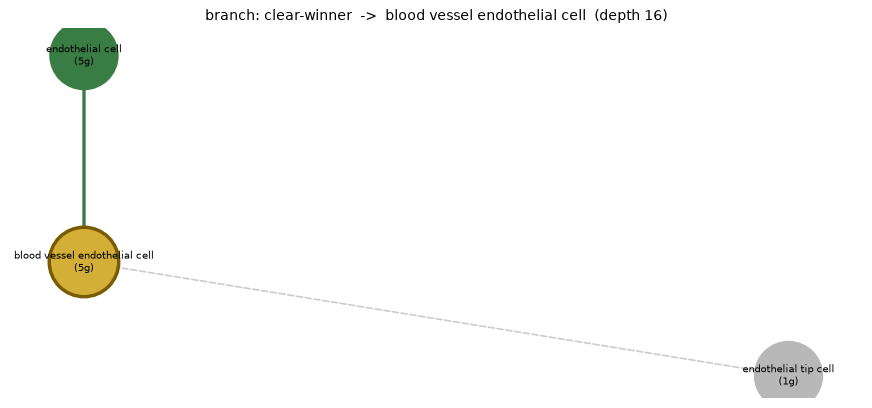

In [8]:
draw_descent(lab.trace(ENDO), lab._zfa_ontology)
plt.show()

## 7 · Stage 5 — Confidence & the packet  (`label.py:363`, `models.py:88`)

Confidence is a weighted blend of four components, each in [0, 1]:
**coherence** (0.40, how much matched-marker weight) · **margin** (0.30, the lead over the runner-up)
· **grounding** (0.20, fraction of markers whose ZFIN expression sits under the named term) ·
**stage** (0.10, fraction on-stage). A hard cap keeps panels-alone honest: *high* requires real
grounding/stage corroboration, so a strong panel with no anatomical support tops out at *medium*.

In the packet below, `levels` is the broad-to-specific chain of non-stoplist ZFA terms ending at
the named term (a union of all ancestor paths in the DAG, not a single clean lineage), and `depth`
is its length — the ancestors plus the named term itself.

In [9]:
L = lab.label(ENDO)
print("confidence:", L.confidence, " score:", L.confidence_score)
for name, val in L.confidence_components.items():
    print(f"  {name:10s} {val:.2f}")

print("\n--- the Label packet, grouped ---")
print("the name      :", L.bucket, "  zfa_id:", L.zfa_id)
print("depth evidence:", "depth", L.depth, "| levels", " > ".join(L.levels))
print("panel prior   :", L.panel_bucket, "(", L.panel_germ_layer, ")")
print("convergence   :", L.convergent_genes)
print("forcing evid. :", "ood", L.ood, "| margin", round(L.margin, 2),
      "| candidates", [c.bucket for c in L.candidates])
print("next step     :", L.next_step)

confidence: high  score: 1.0
  coherence  1.00
  margin     1.00
  grounding  1.00
  stage      1.00

--- the Label packet, grouped ---
the name      : blood vessel endothelial cell   zfa_id: ZFA:0009036
depth evidence: depth 16 | levels cardiovascular system > multi-tissue structure > unilaminar epithelium > portion of tissue > vasculature > simple squamous epithelium > barrier cell > epithelium > cell > vascular endothelium > lining cell > epithelial cell > blood vessel endothelium > endothelial cell > squamous epithelial cell > blood vessel endothelial cell
panel prior   : endothelium ( mesoderm )
convergence   : ('cdh5', 'etsrp', 'fli1', 'kdr', 'kdrl')
forcing evid. : ood in_set | margin 0.85 | candidates ['endothelium']
next step     : subcluster


## 8 · Depth honesty in one glance

The same `label()` call, seven clusters. Watch `depth` track the evidence — deep where the markers
converge on a cell type, shallow where they only agree on a system, **0 (abstain)** where they
contradict. zlabel reports the level the evidence supports and no deeper.

In [10]:
EXAMPLES = {
    "endothelial (deep)":     ["kdrl", "fli1a", "cdh5", "kdr", "etv2"],
    "muscle (honest stop)":   ["mylz2", "acta1b", "tnnt3a", "myod1", "myog", "myf5"],
    "erythroid":              ["gata1a", "hbae1.1", "hbbe2", "alas2", "klf1"],
    "broad neural (shallow)": ["elavl3", "sox2", "sox3", "neurod1", "gfap", "her4.1"],
    "no signal (abstain)":    ["zzz1", "qqq2", "foo3"],
    "specificity rescue":     ["myod1", "actb1", "eef1a1l1", "rps2", "tuba1b"],
    "doublet (abstain)":      ["myod1", "myog", "acta1b", "elavl3", "sox2", "neurod1"],
}
print(f"{'example':24s} {'bucket':30s} {'depth':>5s} {'conf':>7s} {'ood':>11s} {'margin':>6s}")
for name, mk in EXAMPLES.items():
    L = lab.label(mk)
    print(f"{name:24s} {L.bucket:30s} {L.depth:5d} {str(L.confidence):>7s} {L.ood:>11s} {L.margin:6.2f}")

example                  bucket                         depth    conf         ood margin
endothelial (deep)       blood vessel endothelial cell     16    high      in_set   0.85


muscle (honest stop)     musculature system                 1    high      in_set   1.00
erythroid                nucleate erythrocyte               7    high      in_set   1.00


broad neural (shallow)   nervous system                     1    high      in_set   0.87


no signal (abstain)      mixed/unresolved                   0    None   no_signal   0.00
specificity rescue       musculature system                 1  medium      in_set   0.34
doublet (abstain)        mixed/unresolved                   0    None     doublet   0.29


Notice **depth ⊥ confidence**: *broad neural* is shallow (depth 1) yet *high* confidence — the
markers agree strongly, just only at the level of the whole nervous system. And the *specificity
rescue* still names *musculature system* off a single canonical `myod1` buried among housekeeping
genes, the way a scientist would.

## 9 · The forcing evidence on an abstention

Mixing three muscle (mesoderm) and three neural (ectoderm) markers gives contradictory germ
layers — a likely doublet, so zlabel abstains. But it is **not silent**: it hands back the near-tie
`candidates`, the raw `margin`, and an `ood` flag, so a caller who knows better can *force* the top
candidate itself. Honesty without a dead end.

In [11]:
DOUBLET = ["myod1", "myog", "acta1b", "elavl3", "sox2", "neurod1"]   # 3 muscle + 3 neural
L = lab.label(DOUBLET)
print("bucket:", L.bucket, "| abstained:", L.abstained, "| ood:", L.ood, "| margin:", round(L.margin, 2))
print("\nforcing evidence — the near-tie the engine refused to break:")
for c in L.candidates:
    print(f"  {c.bucket:16s} germ_layer={c.germ_layer:9s} adj={c.adjusted_score:.2f}"
          f"  margin_to_top={c.margin_to_top:.2f}")
top = L.candidates[0]
print(f"\nA caller could force candidates[0] ({top.bucket}); but it spans germ layers")
print("(mesoderm vs ectoderm), the signature of a doublet, so zlabel abstains by default.")

bucket: mixed/unresolved | abstained: True | ood: doublet | margin: 0.29

forcing evidence — the near-tie the engine refused to break:
  muscle           germ_layer=mesoderm  adj=0.64  margin_to_top=0.00
  neural           germ_layer=ectoderm  adj=0.36  margin_to_top=0.29

A caller could force candidates[0] (muscle); but it spans germ layers
(mesoderm vs ectoderm), the signature of a doublet, so zlabel abstains by default.


## 10 · Where to go next

- **See it visually.** `../../../zlabel-scope` renders this exact trace as an interactive descent
  DAG plus per-step decision cards (paste any marker list into its runner). It *calls* zlabel — it
  never re-decides.
- **The proof it works.** `benchmarks/daniocell_baseline_report.md` — broad agreement, the
  named/fallback/abstain split, and the parent-child overcall audit on a real atlas. `make gate`
  fails the build if that regresses.
- **The three files to read**, in order: `src/zlabel/resolve.py` (the descent), `src/zlabel/label.py`
  (the ladder + confidence), `src/zlabel/models.py` (the `Label` and the trace).
- **The map.** [`workflow_map.md`](workflow_map.md) — the mental model, every threshold and what it
  guards, the full `Label` field reference, and the design *why*.

*Tweak any marker list above and re-run — that is the fastest way to build intuition for where the
descent stops and why.*